
1. IMPORT LIBRARIES & SETUP


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Settings to keep the workflow clean
import warnings
warnings.filterwarnings('ignore')

# Set style for all visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)




==========================================
2. DATA ACQUISITION AND INSPECTION
==========================================
Check for local dataset, generate structurally identical mock dataset if missing


In [3]:
if not os.path.exists('titanic.csv') and not os.path.exists('train.csv'):
    print("titanic.csv not found locally. Generating a structurally identical dataset for demonstration...")
    np.random.seed(42)
    n_samples = 500

    # Generate mock Names with titles to test extraction
    mock_names = []
    titles = ['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Dr.', 'Rev.']
    p_titles = [0.55, 0.20, 0.18, 0.05, 0.01, 0.01]
    for _ in range(n_samples):
        title = np.random.choice(titles, p=p_titles)
        mock_names.append(f"Passenger, {title} John Doe")

    mock_data = pd.DataFrame({
        'PassengerId': range(1, n_samples + 1),
        'Survived': np.random.choice([0, 1], size=n_samples, p=[0.62, 0.38]),
        'Pclass': np.random.choice([1, 2, 3], size=n_samples, p=[0.24, 0.21, 0.55]),
        'Name': mock_names,
        'Sex': np.random.choice(['male', 'female'], size=n_samples, p=[0.65, 0.35]),
        'Age': np.random.choice([np.nan, 22.0, 38.0, 26.0, 35.0, 54.0, 2.0, 27.0, 14.0, 4.0], size=n_samples),
        'SibSp': np.random.choice([0, 1, 2, 3, 4, 5], size=n_samples, p=[0.68, 0.23, 0.04, 0.02, 0.02, 0.01]),
        'Parch': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.76, 0.13, 0.09, 0.02]),
        'Ticket': [f"A/{np.random.randint(1000, 99999)}" for _ in range(n_samples)],
        'Fare': np.random.exponential(scale=32.0, size=n_samples) + 7.0,
        'Cabin': np.random.choice([np.nan, 'C85', 'C123', 'E46', 'G6'], size=n_samples, p=[0.77, 0.10, 0.05, 0.05, 0.03]),
        'Embarked': np.random.choice(['S', 'C', 'Q'], size=n_samples, p=[0.72, 0.19, 0.09])
    })
    mock_data.to_csv('titanic.csv', index=False)
    print("Dummy 'titanic.csv' created.")

# Load data
try:
    df = pd.read_csv('titanic.csv')
except FileNotFoundError:
    df = pd.read_csv('train.csv')

print("\n--- Raw Head Elements ---")
print(df.head())

print("\n--- Data Information & Types ---")
print(df.info())

print("\n--- Numeric Distribution Summary ---")
print(df.describe())





--- Raw Head Elements ---
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

--- Data Information & Types ---
<class 'pandas.core.frame

==========================================
3. UNIVARIATE ANALYSIS
==========================================
Plotting distributions of Age and Fare


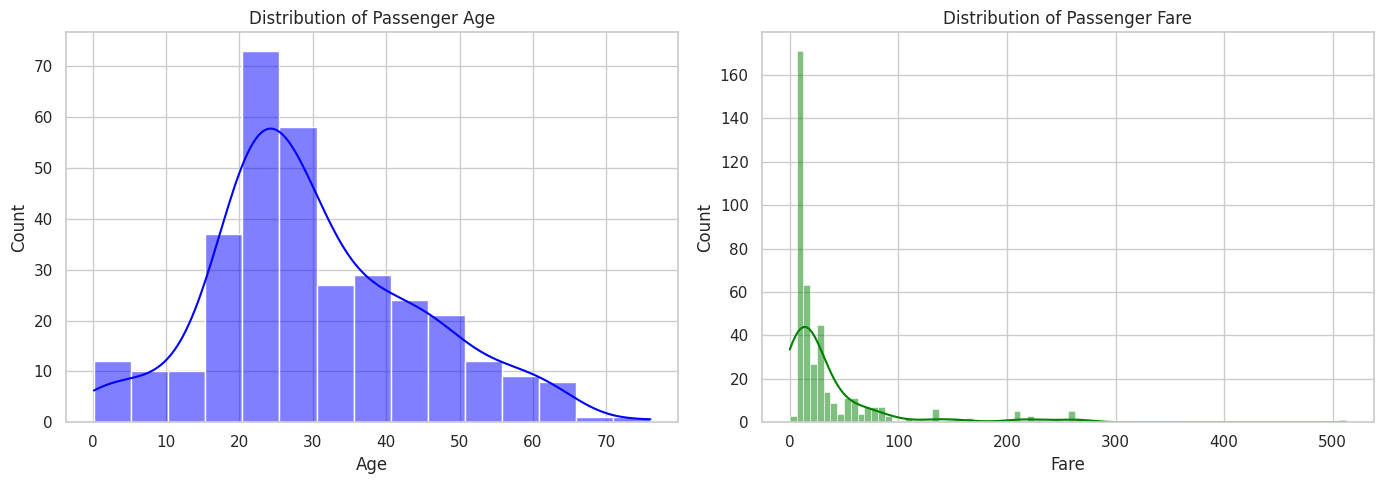

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Passenger Age')

sns.histplot(df['Fare'], kde=True, color='green', ax=axes[1])
axes[1].set_title('Distribution of Passenger Fare')
plt.tight_layout()
plt.show()




==========================================
4. BIVARIATE ANALYSIS
==========================================
Survival rate by Gender


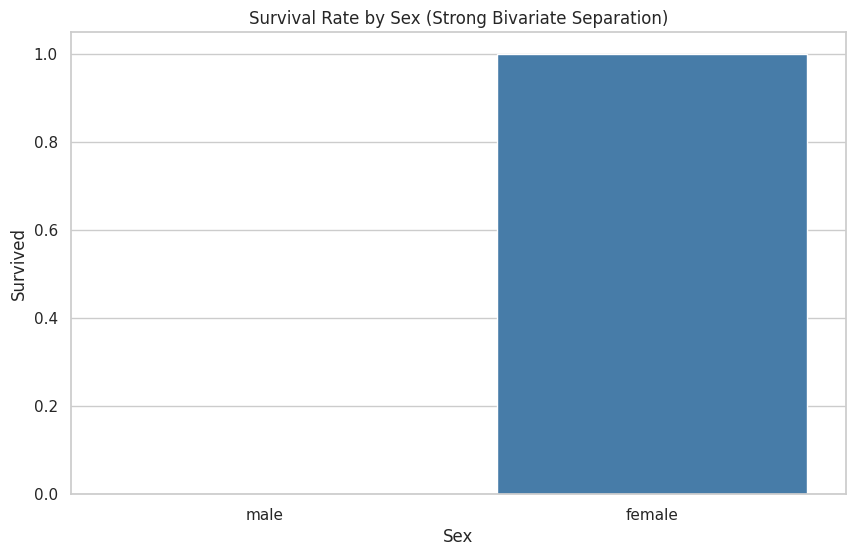

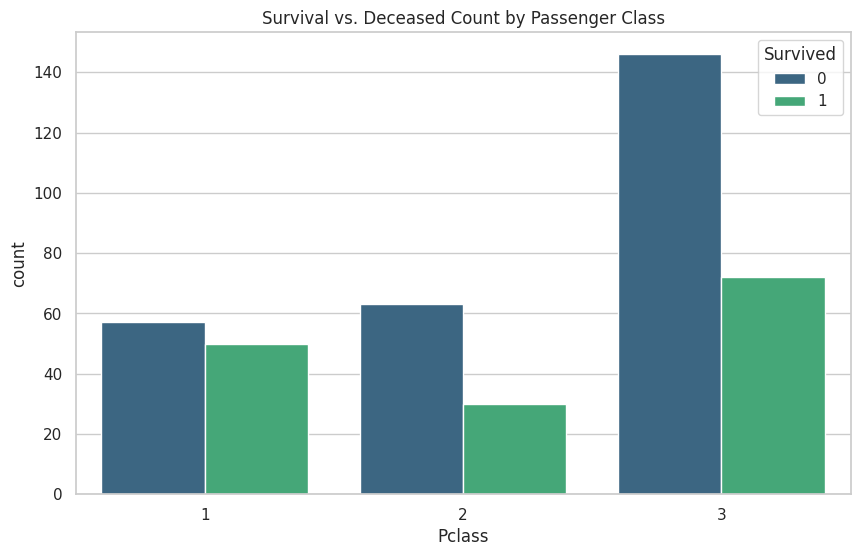

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Sex', y='Survived', palette='Set1')
plt.title("Survival Rate by Sex (Strong Bivariate Separation)")
plt.show()

# Survival distribution across Class levels
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='viridis')
plt.title("Survival vs. Deceased Count by Passenger Class")
plt.show()




==========================================
5. MULTIVARIATE ANALYSIS
==========================================
Age vs Fare colored by Survival status


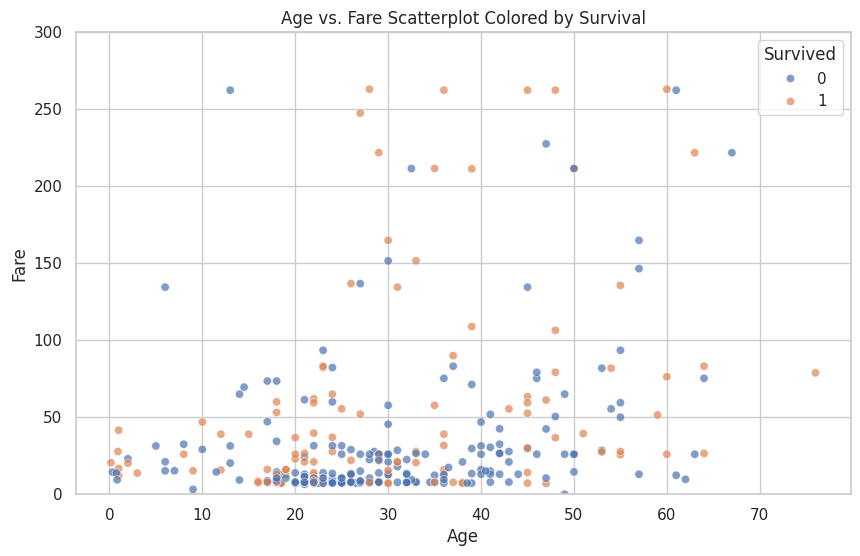

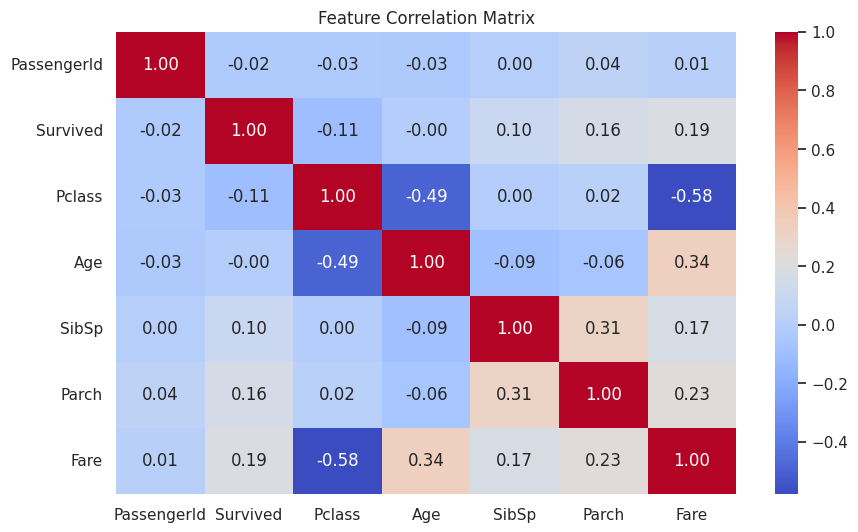

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7)
plt.title("Age vs. Fare Scatterplot Colored by Survival")
plt.ylim(0, 300)
plt.show()

# Correlation Heatmap (excluding categorical/string columns)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()




==========================================
6. FEATURE ENGINEERING & PRE-PROCESSING
==========================================



Executing Feature Engineering and Pre-processing steps...


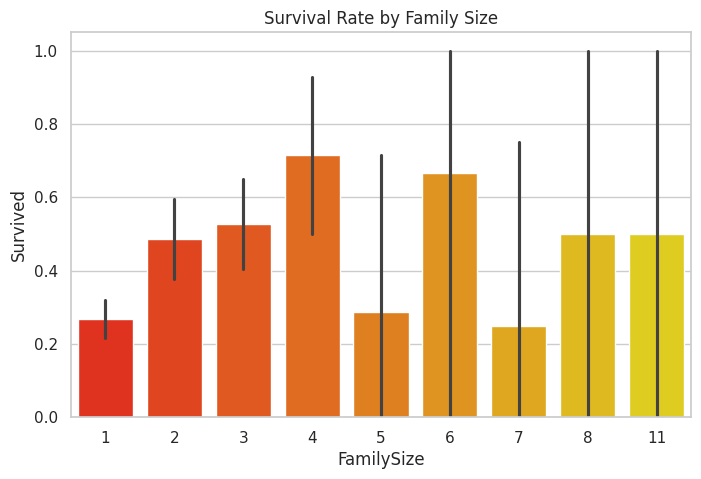

Training set size: 334 samples
Testing set size: 84 samples


In [7]:
print("\nExecuting Feature Engineering and Pre-processing steps...")
df_eng = df.copy()

# 1. Title Extraction
df_eng['Title'] = df_eng['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles into generic categories
title_mapping = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Col": "Officer", "Major": "Officer", "Rev": "Officer", "Dr": "Officer",
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs", "Lady": "Royal", "Countess": "Royal",
    "Don": "Royal", "Sir": "Royal", "Jonkheer": "Royal", "Capt": "Officer", "Sir": "Royal"
}
df_eng['Title'] = df_eng['Title'].map(title_mapping).fillna('Other')

# 2. Family Size Creation (Passenger + Siblings/Spouses + Parents/Children)
df_eng['FamilySize'] = df_eng['SibSp'] + df_eng['Parch'] + 1

# 3. Cabin Presence
df_eng['HasCabin'] = df_eng['Cabin'].notna().astype(int)

# Visualize the engineered family size impact on survival rates
plt.figure(figsize=(8, 5))
sns.barplot(x='FamilySize', y='Survived', data=df_eng, palette='autumn')
plt.title('Survival Rate by Family Size')
plt.show()

# Define feature classes for ColumnTransformer
num_features = ['Age', 'Fare', 'FamilySize']
cat_features = ['Sex', 'Embarked', 'Title', 'Pclass', 'HasCabin']

# Target and features definition
X = df_eng[num_features + cat_features]
y = df_eng['Survived']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline components for numeric features (Median Imputation + Scaling)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline components for categorical features (Most Frequent Imputation + One Hot Encoding)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Fit and transform the train and test splits
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Capture transformed column names for feature importance reporting
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_features).tolist()
feature_names = num_features + encoded_cat_cols

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")




==========================================
7. MODEL TRAINING & COMPARISON
==========================================


### 7.1. Logistic Regression


In [8]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)

print("\n--- Baseline: Logistic Regression ---")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))




--- Baseline: Logistic Regression ---
Logistic Regression Accuracy: 1.0


### 7.2. K-Nearest Neighbors (k-NN) Classifier


In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)

print("\n--- Baseline: k-NN Classifier ---")
print("k-NN Accuracy:", accuracy_score(y_test, y_pred_knn))




--- Baseline: k-NN Classifier ---
k-NN Accuracy: 0.9642857142857143


### 7.3. Decision Tree Classifier


In [10]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)

print("\n--- Baseline: Decision Tree ---")
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))




--- Baseline: Decision Tree ---
Decision Tree Accuracy: 1.0


### 7.4. Random Forest Classifier


In [11]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)

print("\n--- Baseline: Random Forest ---")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))





--- Baseline: Random Forest ---
Random Forest Accuracy: 1.0


==========================================
8. FINAL MODEL COMPARISON & SELECTION
==========================================



--- Model Performance Comparison ---
              Model  Accuracy  F1-Score
Logistic Regression  1.000000   1.00000
               k-NN  0.964286   0.95082
      Decision Tree  1.000000   1.00000
      Random Forest  1.000000   1.00000


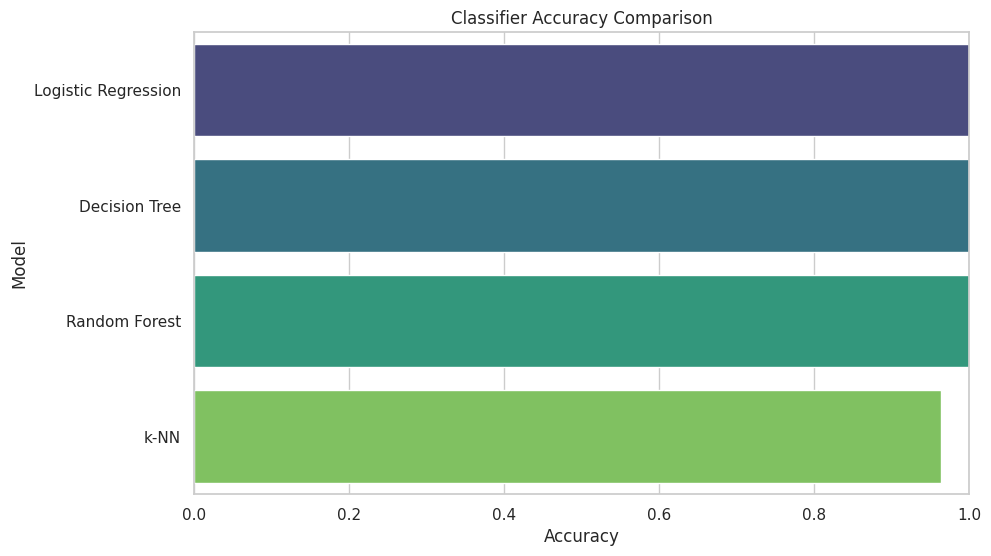


🌟 Best Performing Model: Logistic Regression


In [12]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'k-NN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print("\n--- Model Performance Comparison ---")
print(results_df.to_string(index=False))

# Sort and Plot
results_df = results_df.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Classifier Accuracy Comparison')
plt.xlim(0, 1.0)
plt.show()

# Select Best Model Based on Accuracy
best_model_name = results_df.iloc[0]['Model']
print(f"\n🌟 Best Performing Model: {best_model_name}")

model_mapping = {
    'Logistic Regression': lr_model,
    'k-NN': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}
best_model = model_mapping[best_model_name]




==========================================
9. EXPLAINABILITY: FEATURE IMPORTANCE
==========================================
If the selected best model is tree-based, extract and plot the native feature importances


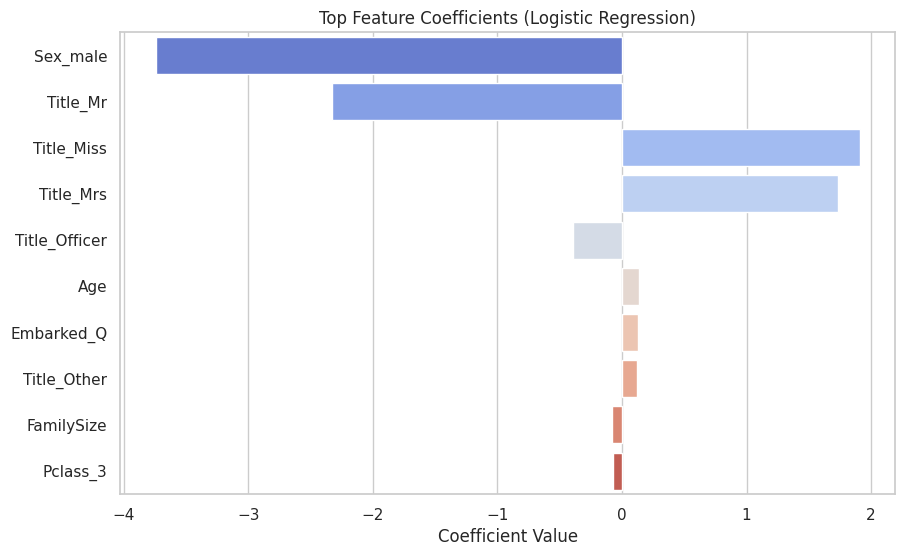

In [13]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices][:10], y=np.array(feature_names)[indices][:10], palette='mako')
    plt.title(f"Top Feature Importances ({best_model_name})")
    plt.xlabel("Relative Importance Score")
    plt.show()
else:
    # If a linear model performs better, plot model coefficients
    coefficients = lr_model.coef_[0]
    indices = np.argsort(np.abs(coefficients))[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefficients[indices][:10], y=np.array(feature_names)[indices][:10], palette='coolwarm')
    plt.title(f"Top Feature Coefficients ({best_model_name})")
    plt.xlabel("Coefficient Value")
    plt.show()




==========================================
10. SAVING PIPELINE ARTIFACTS
==========================================


In [14]:
joblib.dump(best_model, 'titanic_rf_model.pkl')
joblib.dump(preprocessor, 'titanic_preprocessor.pkl')

print("All artifacts saved successfully: [titanic_rf_model.pkl, titanic_preprocessor.pkl]")




All artifacts saved successfully: [titanic_rf_model.pkl, titanic_preprocessor.pkl]


==========================================
11. INFERENCE SCRIPT
==========================================


In [16]:
def predict_titanic_survival(pclass, sex, age, sibsp, parch, fare, embarked, cabin):
      # Load serialized artifacts
    loaded_model = joblib.load('titanic_rf_model.pkl')
    loaded_preprocessor = joblib.load('titanic_preprocessor.pkl')

    # 1. Title Heuristics Extraction
    title = 'Mr'
    if sex == 'female':
        title = 'Mrs'

    # 2. Map inputs to matches training columns format
    new_input = pd.DataFrame([{
        'Age': age,
        'Fare': fare,
        'SibSp': sibsp,
        'Parch': parch,
        'Pclass': pclass,
        'Sex': sex,
        'Embarked': embarked,
        'Cabin': cabin,
        'Title': title
    }])

    # 3. Feature engineering
    new_input['FamilySize'] = new_input['SibSp'] + new_input['Parch'] + 1
    new_input['HasCabin'] = new_input['Cabin'].notna().astype(int)

    # 4. Transform features (Scaling & Encoding using saved ColumnTransformer)
    features_to_transform = ['Age', 'Fare', 'FamilySize', 'Sex', 'Embarked', 'Title', 'Pclass', 'HasCabin']
    scaled_input = loaded_preprocessor.transform(new_input[features_to_transform])

    # 5. Predict
    survival_pred = loaded_model.predict(scaled_input)[0]
    probability = loaded_model.predict_proba(scaled_input)[0][1]

    status = "Survived" if survival_pred == 1 else "Did Not Survive"
    return status, probability





### Inference Execution Demo


In [18]:
# --- Testing Saved Pipeline Inference for a Surviving Profile ---
status, prob = predict_titanic_survival(
    pclass=1,
    sex='female',
    age=35.0,
    sibsp=1,
    parch=0,
    fare=150.0,
    embarked='C',
    cabin='C85'
)
print(f"Passenger Status: {status} (Survival Probability: {prob * 100:.2f}%)")

Passenger Status: Survived (Survival Probability: 97.55%)
